In [39]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
from sklearn.preprocessing import OneHotEncoder

from sklearn.model_selection import train_test_split


In [2]:
data=pd.read_csv('beer-servings_ML.csv')
data

,Unnamed: 0,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,continent
0,0,Afghanistan,0.0,0.0,0.0,0.0,Asia
1,1,Albania,89.0,132.0,54.0,4.9,Europe
2,2,Algeria,25.0,0.0,14.0,0.7,Africa
3,3,Andorra,245.0,138.0,312.0,12.4,Europe
4,4,Angola,217.0,57.0,45.0,5.9,Africa
...,...,...,...,...,...,...,...
188,188,Venezuela,NaN,100.0,3.0,7.7,South America
189,189,Vietnam,111.0,2.0,1.0,2.0,Asia
190,190,Yemen,6.0,0.0,0.0,0.1,Asia
191,191,Zambia,32.0,19.0,4.0,2.5,Africa


In [3]:
data.head()

,Unnamed: 0,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,continent
0,0,Afghanistan,0.0,0.0,0.0,0.0,Asia
1,1,Albania,89.0,132.0,54.0,4.9,Europe
2,2,Algeria,25.0,0.0,14.0,0.7,Africa
3,3,Andorra,245.0,138.0,312.0,12.4,Europe
4,4,Angola,217.0,57.0,45.0,5.9,Africa


In [4]:
data.tail()

,Unnamed: 0,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,continent
188,188,Venezuela,NaN,100.0,3.0,7.7,South America
189,189,Vietnam,111.0,2.0,1.0,2.0,Asia
190,190,Yemen,6.0,0.0,0.0,0.1,Asia
191,191,Zambia,32.0,19.0,4.0,2.5,Africa
192,192,Zimbabwe,64.0,18.0,4.0,4.7,Africa


In [5]:
data.isna().sum()

Unnamed: 0                      0
country                         0
beer_servings                   8
spirit_servings                 8
wine_servings                   6
total_litres_of_pure_alcohol    1
continent                       0
dtype: int64

In [6]:
data.duplicated().sum()

np.int64(0)

In [7]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 193 entries, 0 to 192
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Unnamed: 0                    193 non-null    int64  
 1   country                       193 non-null    str    
 2   beer_servings                 185 non-null    float64
 3   spirit_servings               185 non-null    float64
 4   wine_servings                 187 non-null    float64
 5   total_litres_of_pure_alcohol  192 non-null    float64
 6   continent                     193 non-null    str    
dtypes: float64(4), int64(1), str(2)
memory usage: 10.7 KB


In [8]:
data.describe()

,Unnamed: 0,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol
count,193.000000,185.000000,185.000000,187.000000,192.000000
mean,96.000000,105.124324,83.221622,50.165775,4.741667
std,55.858452,100.524714,89.142958,80.358868,3.767654
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,20.000000,4.000000,1.000000,1.300000
50%,96.000000,76.000000,60.000000,9.000000,4.250000
75%,144.000000,185.000000,132.000000,60.500000,7.200000
max,192.000000,376.000000,438.000000,370.000000,14.400000


In [14]:
data['beer_servings']=data['beer_servings'].fillna(data['beer_servings'].median())
data['spirit_servings']=data['spirit_servings'].fillna(data['spirit_servings'].median())
data['wine_servings']=data['wine_servings'].fillna(data['wine_servings'].median())
data['total_litres_of_pure_alcohol']=data['total_litres_of_pure_alcohol'].fillna(data['total_litres_of_pure_alcohol'].median())
data

,Unnamed: 0,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,continent
0,0,Afghanistan,0.0,0.0,0.0,0.0,Asia
1,1,Albania,89.0,132.0,54.0,4.9,Europe
2,2,Algeria,25.0,0.0,14.0,0.7,Africa
3,3,Andorra,245.0,138.0,312.0,12.4,Europe
4,4,Angola,217.0,57.0,45.0,5.9,Africa
...,...,...,...,...,...,...,...
188,188,Venezuela,76.0,100.0,3.0,7.7,South America
189,189,Vietnam,111.0,2.0,1.0,2.0,Asia
190,190,Yemen,6.0,0.0,0.0,0.1,Asia
191,191,Zambia,32.0,19.0,4.0,2.5,Africa


In [16]:
data.isna().sum()

Unnamed: 0                      0
country                         0
beer_servings                   0
spirit_servings                 0
wine_servings                   0
total_litres_of_pure_alcohol    0
continent                       0
dtype: int64

In [21]:
a=data.select_dtypes(include='number').corr()
a


,Unnamed: 0,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol
Unnamed: 0,1.000000,-0.063332,-0.074295,-0.078372,-0.061869
beer_servings,-0.063332,1.000000,0.462890,0.537475,0.829418
spirit_servings,-0.074295,0.462890,1.000000,0.191385,0.657077
wine_servings,-0.078372,0.537475,0.191385,1.000000,0.669937
total_litres_of_pure_alcohol,-0.061869,0.829418,0.657077,0.669937,1.000000


<Axes: >

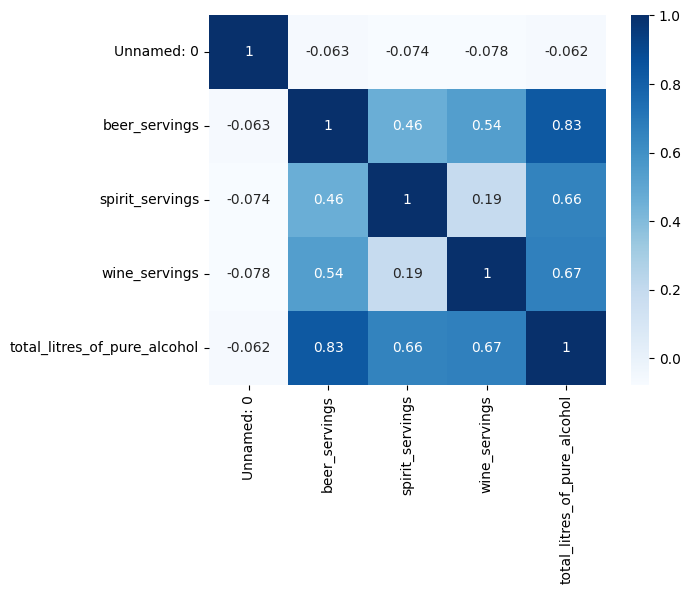

In [22]:
sns.heatmap(a,annot=True,cmap='Blues')

<Axes: >

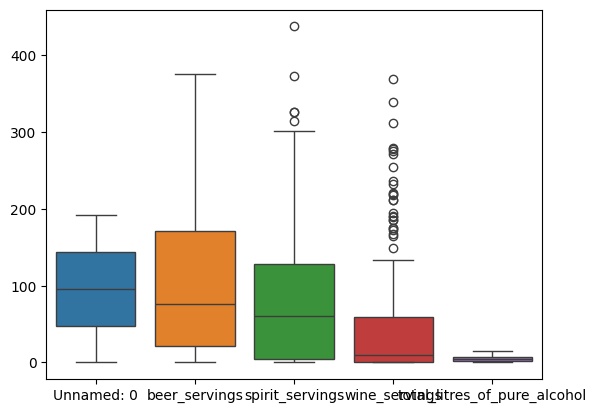

In [23]:
sns.boxplot(data)

# IQR METHOD

THE IQR METHOD IS THE RANGE BETWEEN THE FIRST QUARTILE (Q1 OR 25TH PERCENTILE)AND THE THIRD QUARTILE(Q3 OR 75TH PERCENTILE) OF THE DATA.  IT GIVES THE IDEA OF THE SPREAD OF THE MIDDLE 50%  OF THE DATA

In [31]:
Q1=np.percentile(data['spirit_servings'],25,method='midpoint')
Q2=np.percentile(data['spirit_servings'],50,method='midpoint')
Q3=np.percentile(data['spirit_servings'],75,method='midpoint')

#method='midpoint' parameter specifyes how to interpolite beteween data points when the desired percentile lies between two data points

#25th percentile falls beteween two data points,the result will be the average of those two points

print('Q1 is ',Q1)
print('Q2 is',Q2)
print('Q3 is ',Q3)

Q1 is  5.0
Q2 is 60.0
Q3 is  128.0


In [32]:
IQR=Q3-Q1
print(IQR)

123.0


In [33]:
low_lim=Q1-1.5* IQR
up_lim=Q3+ 1.5 * IQR

print("lower value=",low_lim)
print('upper value',up_lim)

lower value= -179.5
upper value 312.5


In [34]:
outliers=[]
for x in data['spirit_servings']:
    if ((x<low_lim)or (x>up_lim)):
        outliers.append(x)
print(outliers)

[373.0, 438.0, 326.0, 326.0, 315.0]


# CLIPPING
when using the IQR method to detect the outlier clipping help handling the extreme values by limiting their values by limiting their effect on the data

LOWER CLIPPING:- if a data point is below the lower bound it is cliped to the lower bound value

UPPER CLIPPING:- if a data point is above the upper bound. it is clipped to the upper bound value

CLIPPING IN the IQR method is a way to handle outliers without removing them from the dataset

it ensures that  extreme values dont disproportionately affect model training or statistical analysis

it improves the stability of ML models , preserves data points and ensures proper scaling of features



In [35]:
data['spirit_servings']=data['spirit_servings'].clip(lower=low_lim,upper=up_lim)

{'whiskers': [<matplotlib.lines.Line2D at 0x1e59c9ea510>,
 'caps': [<matplotlib.lines.Line2D at 0x1e59c9ea7b0>,
 'boxes': [<matplotlib.lines.Line2D at 0x1e59c9ea3c0>],
 'medians': [<matplotlib.lines.Line2D at 0x1e59c9eaa50>],
 'fliers': [<matplotlib.lines.Line2D at 0x1e59c9eaba0>],
 'means': []}

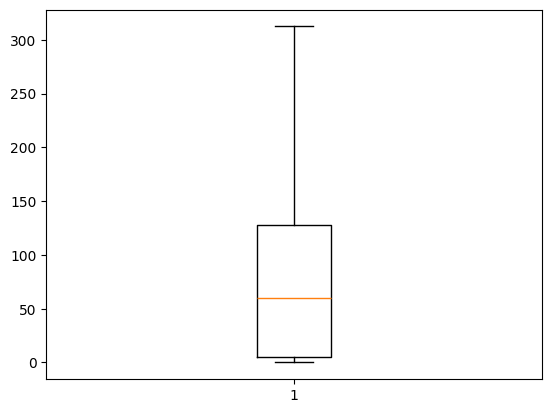

In [40]:
plt.boxplot(data['spirit_servings'])

# Z SCORE

In [41]:
from scipy.stats import zscore

In [42]:
z_scores=zscore(data['wine_servings'])
print(z_scores)

[-0.61716197  0.06456162 -0.44041882  3.32168545 -0.04905898 -0.04905898
  2.17285495 -0.47829235  2.05923435  1.79411962 -0.55403942  0.02668809
 -0.5287904  -0.50354138 -0.16267958 -0.08693251  2.05923435 -0.51616589
 -0.45304333 -0.61716197 -0.51616589 -0.51616589 -0.17530409 -0.4151698
 -0.60453746  0.56954206 -0.5287904  -0.61716197 -0.5287904  -0.4151698
 -0.60453746 -0.56666393  0.64528912 -0.60453746 -0.60453746  1.55425391
 -0.51616589 -0.57928844 -0.60453746 -0.50354138  0.31705184 -0.47829235
  2.58946381 -0.55403942  0.80940777  1.0745225  -0.61716197 -0.60453746
  2.89245207 -0.57928844 -0.28892469 -0.50354138 -0.50354138 -0.60453746
 -0.59191295  2.32434908 -0.61716197  0.12768417 -0.61716197 -0.60453746
  0.60741559  4.05390708  0.12768417 -0.60453746  1.26389016  1.59212745
 -0.49091686  2.13498142 -0.26367567 -0.59191295 -0.59191295 -0.35204724
 -0.60453746 -0.60453746 -0.50354138  1.71837255  0.36754988 -0.61716197
 -0.61716197 -0.61716197 -0.61716197  1.46588234 -0.5

In [44]:
threshold= .5

outliers_index=data.index[(z_scores>threshold)|(z_scores< -threshold)]
print(outliers_index)

Index([  0,   3,   6,   8,   9,  10,  12,  13,  16,  17,
       ...
       181, 182, 183, 185, 186, 188, 189, 190, 191, 192],
      dtype='int64', length=143)


In [45]:
data1=data.drop(outliers_index)
data1.head(10)

,Unnamed: 0,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,continent
1,1,Albania,89.0,132.0,54.0,4.9,Europe
2,2,Algeria,25.0,0.0,14.0,0.7,Africa
4,4,Angola,217.0,57.0,45.0,5.9,Africa
5,5,Antigua & Barbuda,102.0,128.0,45.0,4.9,North America
7,7,Armenia,21.0,179.0,11.0,3.8,Europe
11,11,Bahamas,122.0,176.0,51.0,6.3,North America
14,14,Barbados,143.0,173.0,36.0,6.3,North America
15,15,Belarus,142.0,312.5,42.0,14.4,Europe
18,18,Benin,34.0,4.0,13.0,1.1,Africa
22,22,Botswana,173.0,35.0,35.0,5.4,Africa


{'whiskers': [<matplotlib.lines.Line2D at 0x1e59ccf8590>,
 'caps': [<matplotlib.lines.Line2D at 0x1e59ccf8830>,
 'boxes': [<matplotlib.lines.Line2D at 0x1e59ccf8440>],
 'medians': [<matplotlib.lines.Line2D at 0x1e59ccf8ad0>],
 'fliers': [<matplotlib.lines.Line2D at 0x1e59ccf8c20>],
 'means': []}

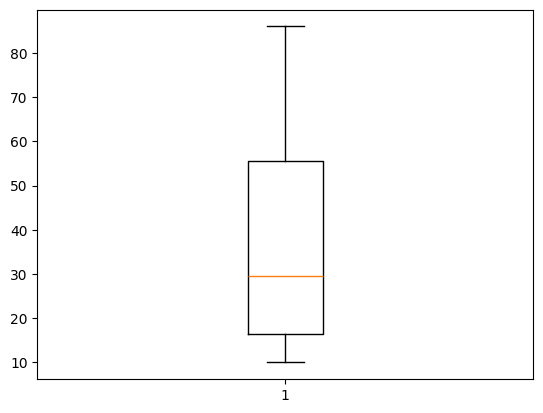

In [46]:
plt.boxplot(data1['wine_servings'])

In [47]:
data.shape

(193, 7)

In [48]:
data1.shape

(50, 7)